In [ ]:
# !pip install ucimlrepo

In [ ]:
# Import Required Libraries

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Models
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# UCI Dataset Loader
from ucimlrepo import fetch_ucirepo

import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Load Dataset (UCI Spambase)

spambase = fetch_ucirepo(id=94)

# Features and Target
X = spambase.data.features
y = spambase.data.targets

In [ ]:
# Basic Inspection

print("Dataset Shape (X):", X.shape)
print("Target Shape (y):", y.shape)

print("\nFirst 5 rows:")
print(X.head())

print("\nTarget distribution:")
print(y.value_counts())

# Metadata
print("\nMetadata:")
print(spambase.metadata)

# Variable Information
print("\nVariable Info:")
print(spambase.variables)

Dataset Shape (X): (4601, 57)
Target Shape (y): (4601, 1)

First 5 rows:
   word_freq_make  word_freq_address  word_freq_all  word_freq_3d  \
0            0.00               0.64           0.64           0.0   
1            0.21               0.28           0.50           0.0   
2            0.06               0.00           0.71           0.0   
3            0.00               0.00           0.00           0.0   
4            0.00               0.00           0.00           0.0   

   word_freq_our  word_freq_over  word_freq_remove  word_freq_internet  \
0           0.32            0.00              0.00                0.00   
1           0.14            0.28              0.21                0.07   
2           1.23            0.19              0.19                0.12   
3           0.63            0.00              0.31                0.63   
4           0.63            0.00              0.31                0.63   

   word_freq_order  word_freq_mail  ...  word_freq_conference  char

In [ ]:
# PREPROCESSING

# Convert target to 1D
y = y.squeeze()

# Check missing values
print("Missing values in X:\n", X.isnull().sum().sum())

# No missing values → no imputation needed

# Check class distribution
print("\nClass Distribution:\n", y.value_counts(normalize=True))

Missing values in X:
 0

Class Distribution:
 Class
0    0.605955
1    0.394045
Name: proportion, dtype: float64


In [ ]:
#FEATURE ENGINEERING

# TEXT FEATURES
text_features = [col for col in X.columns if "word_freq" in col or "char_freq" in col]

# METADATA FEATURES
metadata_features = [
    "capital_run_length_average",
    "capital_run_length_longest",
    "capital_run_length_total"
]

# Custom engineered features (NEW)
X["total_word_freq"] = X[[col for col in X.columns if "word_freq" in col]].sum(axis=1)
X["total_char_freq"] = X[[col for col in X.columns if "char_freq" in col]].sum(axis=1)

X["capital_ratio"] = X["capital_run_length_total"] / (X["capital_run_length_average"] + 1)

X["spam_indicator"] = (
    X.get("word_freq_free", 0) +
    X.get("word_freq_money", 0) +
    X.get("word_freq_offer", 0)
)

# FINAL FEATURE SETS
X_text = X[text_features]
X_meta = X[metadata_features]
X_combined = X.copy()

In [ ]:
# MANUAL CLASS BALANCING

def manual_oversample(X, y):
    data = pd.concat([X, y], axis=1)

    class_0 = data[data[y.name] == 0]
    class_1 = data[data[y.name] == 1]

    if len(class_0) > len(class_1):
        majority = class_0
        minority = class_1
    else:
        majority = class_1
        minority = class_0

    minority_upsampled = minority.sample(
        n=len(majority),
        replace=True,
        random_state=42
    )

    balanced_data = pd.concat([majority, minority_upsampled])
    balanced_data = balanced_data.sample(frac=1, random_state=42)

    X_bal = balanced_data.drop(columns=[y.name])
    y_bal = balanced_data[y.name]

    return X_bal, y_bal

In [ ]:
import numpy as np

def custom_train_test_split(X, y, test_size=0.2, random_state=42):

    np.random.seed(random_state)

    # Convert to numpy if needed
    X = X.values if hasattr(X, "values") else X
    y = y.values if hasattr(y, "values") else y

    # Separate classes
    class_0_idx = np.where(y == 0)[0]
    class_1_idx = np.where(y == 1)[0]

    # Shuffle indices
    np.random.shuffle(class_0_idx)
    np.random.shuffle(class_1_idx)

    # Split size
    split_0 = int(len(class_0_idx) * (1 - test_size))
    split_1 = int(len(class_1_idx) * (1 - test_size))

    # Train/Test indices
    train_idx = np.concatenate([class_0_idx[:split_0], class_1_idx[:split_1]])
    test_idx = np.concatenate([class_0_idx[split_0:], class_1_idx[split_1:]])

    # Shuffle final sets
    np.random.shuffle(train_idx)
    np.random.shuffle(test_idx)

    # Split data
    X_train = X[train_idx]
    X_test = X[test_idx]
    y_train = y[train_idx]
    y_test = y[test_idx]

    return X_train, X_test, y_train, y_test

In [ ]:
# Split FIRST (on original unbalanced data)
X_train_text_raw, X_test_text_raw, y_train_raw, y_test = custom_train_test_split(X_text, y, test_size=0.2)
X_train_meta_raw, X_test_meta_raw, _, _ = custom_train_test_split(X_meta, y, test_size=0.2)
X_train_comb_raw, X_test_comb_raw, _, _ = custom_train_test_split(X_combined, y, test_size=0.2)

# Oversample ONLY the training set
X_train_text_bal, y_train = manual_oversample(pd.DataFrame(X_train_text_raw), pd.Series(y_train_raw, name='Class'))
X_train_meta_bal, _ = manual_oversample(pd.DataFrame(X_train_meta_raw), pd.Series(y_train_raw, name='Class'))
X_train_comb_bal, _ = manual_oversample(pd.DataFrame(X_train_comb_raw), pd.Series(y_train_raw, name='Class'))

In [ ]:
import numpy as np

class CustomStandardScaler:

    def fit(self, X):
        self.mean_ = np.mean(X, axis=0)
        self.std_ = np.std(X, axis=0)

        # Avoid division by zero
        self.std_[self.std_ == 0] = 1

    def transform(self, X):
        return (X - self.mean_) / self.std_

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

In [ ]:
# Scale AFTER oversampling — fit on train only, transform both
scaler_text = CustomStandardScaler()
X_train_text = scaler_text.fit_transform(X_train_text_bal.values)
X_test_text  = scaler_text.transform(X_test_text_raw)

scaler_meta = CustomStandardScaler()
X_train_meta = scaler_meta.fit_transform(X_train_meta_bal.values)
X_test_meta  = scaler_meta.transform(X_test_meta_raw)

scaler_comb = CustomStandardScaler()
X_train_comb = scaler_comb.fit_transform(X_train_comb_bal.values)
X_test_comb  = scaler_comb.transform(X_test_comb_raw)

In [ ]:
# Verify
print("Train class distribution:", np.bincount(y_train))
print("Test class distribution:", np.bincount(y_test))

Train class distribution: [2230 2230]
Test class distribution: [558 363]


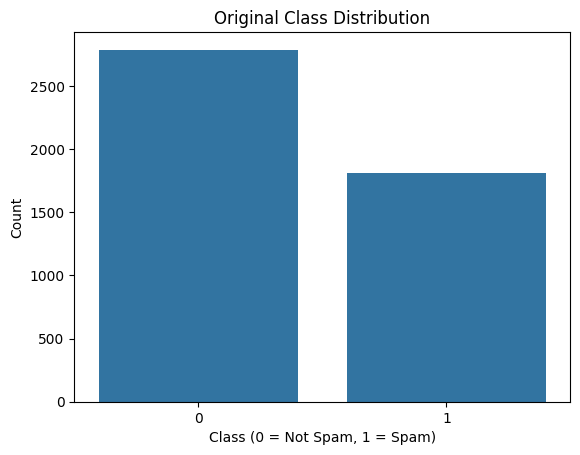

In [ ]:
# Class Distribution (Before Balancing)
sns.countplot(x=y)
plt.title("Original Class Distribution")
plt.xlabel("Class (0 = Not Spam, 1 = Spam)")
plt.ylabel("Count")
plt.show()

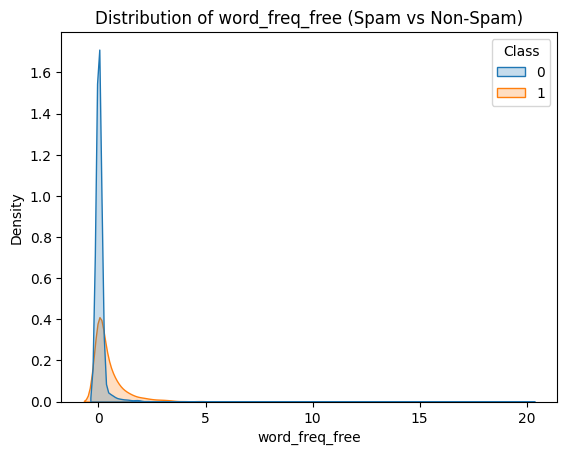

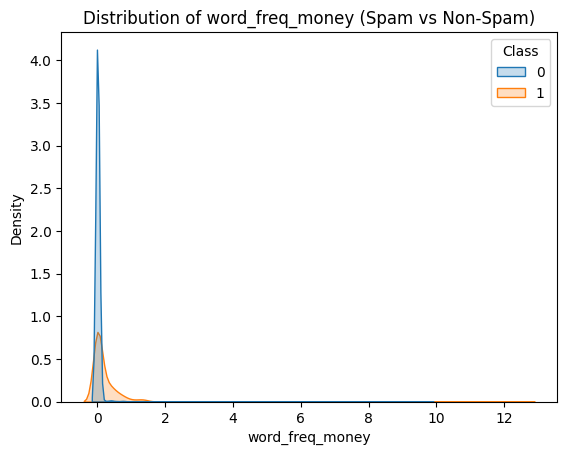

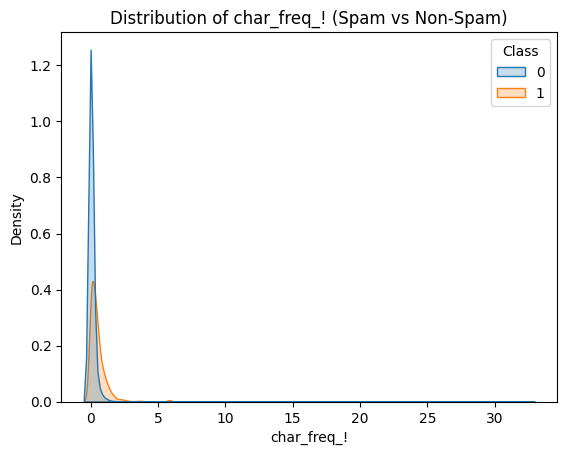

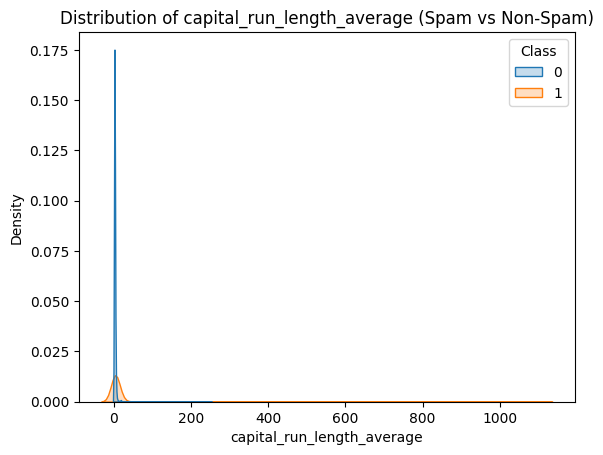

In [ ]:
# Feature Distribution (Key Spam Indicators)
features = ['word_freq_free', 'word_freq_money', 'char_freq_!', 'capital_run_length_average']

for f in features:
    sns.kdeplot(data=X, x=f, hue=y, fill=True)
    plt.title(f"Distribution of {f} (Spam vs Non-Spam)")
    plt.show()

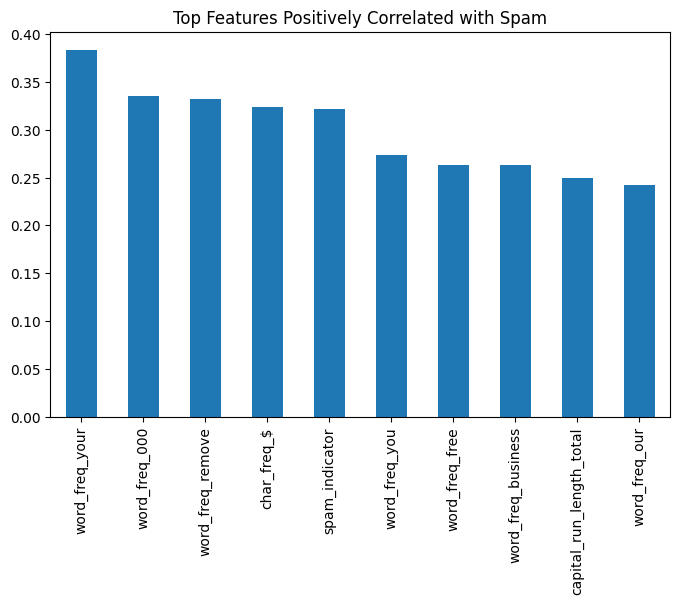

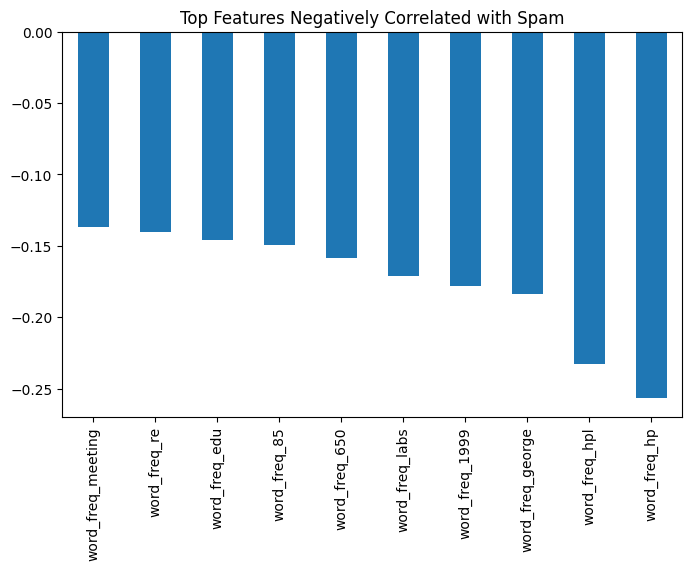

In [ ]:
# Correlation with Target
df = X.copy()
df['Class'] = y

corr = df.corr()['Class'].drop('Class').sort_values(ascending=False)

plt.figure(figsize=(8,5))
corr.head(10).plot(kind='bar')
plt.title("Top Features Positively Correlated with Spam")
plt.show()

plt.figure(figsize=(8,5))
corr.tail(10).plot(kind='bar')
plt.title("Top Features Negatively Correlated with Spam")
plt.show()

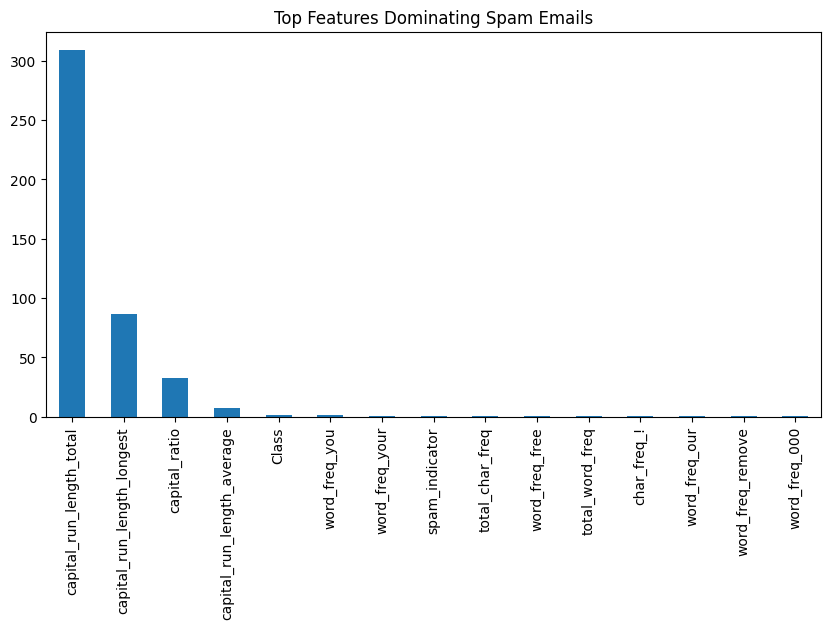

In [ ]:
# Spam vs Non-Spam Feature Difference
spam_mean = df[df['Class']==1].mean()
nonspam_mean = df[df['Class']==0].mean()

diff = (spam_mean - nonspam_mean).sort_values(ascending=False)

diff.head(15).plot(kind='bar', figsize=(10,5))
plt.title("Top Features Dominating Spam Emails")
plt.show()

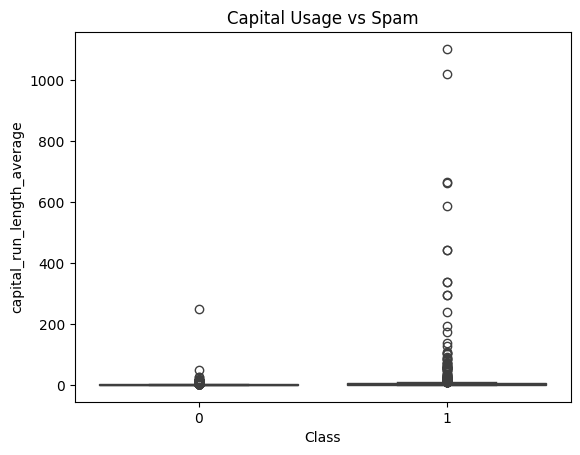

In [ ]:
# Capital Letter Behavior
sns.boxplot(x='Class', y='capital_run_length_average', data=df)
plt.title("Capital Usage vs Spam")
plt.show()

In [ ]:
class CustomPCA:

    def __init__(self, n_components):
        self.n_components = n_components

    def fit(self, X):
        # Covariance matrix
        cov_matrix = np.cov(X, rowvar=False)

        # Eigen decomposition
        eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

        # Sort eigenvalues & eigenvectors
        idx = np.argsort(eigenvalues)[::-1]
        self.eigenvalues_ = eigenvalues[idx]
        self.eigenvectors_ = eigenvectors[:, idx]

        # Select top components
        self.components_ = self.eigenvectors_[:, :self.n_components]

    def transform(self, X):
        return np.dot(X, self.components_)

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

In [ ]:
# Convert to numpy (important)
X_np = X.values if hasattr(X, "values") else X

# Scaling (scratch)
scaler = CustomStandardScaler()
X_scaled = scaler.fit_transform(X_np)

# PCA (scratch)
pca = CustomPCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

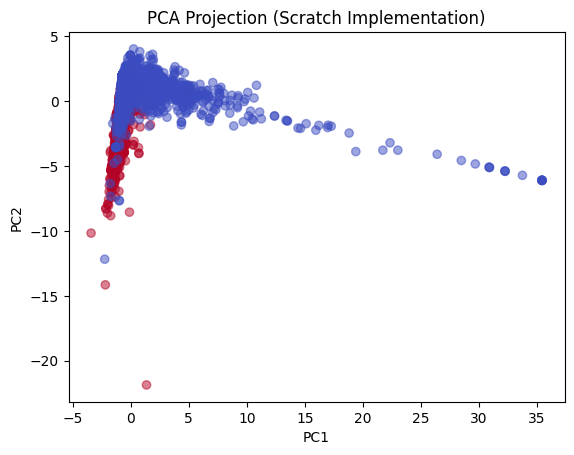

In [ ]:
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='coolwarm', alpha=0.5)
plt.title("PCA Projection (Scratch Implementation)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [ ]:
explained_variance = pca.eigenvalues_ / np.sum(pca.eigenvalues_)
print("Explained Variance (Top 2 PCs):", explained_variance[:2])

Explained Variance (Top 2 PCs): [0.1139105  0.06080218]


In [ ]:
# MODEL DEFINITIONS

from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

models = {
    "Naive Bayes": GaussianNB(),

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        solver='lbfgs'
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    "SVM": SVC(
        kernel='rbf',
        probability=True
    )
}

In [ ]:
def confusion_matrix_elements(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))

    return TP, TN, FP, FN

In [ ]:
def accuracy_score_custom(y_true, y_pred):
    TP, TN, FP, FN = confusion_matrix_elements(y_true, y_pred)
    return (TP + TN) / (TP + TN + FP + FN)

def precision_score_custom(y_true, y_pred):
    TP, _, FP, _ = confusion_matrix_elements(y_true, y_pred)
    return TP / (TP + FP) if (TP + FP) != 0 else 0

def recall_score_custom(y_true, y_pred):
    TP, _, _, FN = confusion_matrix_elements(y_true, y_pred)
    return TP / (TP + FN) if (TP + FN) != 0 else 0

def f1_score_custom(y_true, y_pred):
    precision = precision_score_custom(y_true, y_pred)
    recall = recall_score_custom(y_true, y_pred)
    return (2 * precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

In [ ]:
# EVALUATION FUNCTION

def evaluate_custom(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    return {
        "Accuracy": accuracy_score_custom(y_test, y_pred),
        "Precision": precision_score_custom(y_test, y_pred),
        "Recall": recall_score_custom(y_test, y_pred),
        "F1 Score": f1_score_custom(y_test, y_pred)
    }

In [ ]:
def print_confusion_matrix(y_true, y_pred):
    TP, TN, FP, FN = confusion_matrix_elements(y_true, y_pred)

    print("Confusion Matrix:")
    print(f"TP: {TP}, FP: {FP}")
    print(f"FN: {FN}, TN: {TN}")

In [ ]:
# PROPOSED METHOD:
# Adaptive Feature Weighting Framework (AFWF)

candidate_weights = [0.2, 0.4, 0.6, 0.8]

weighted_datasets = {}

for alpha in candidate_weights:

    weighted_train = np.hstack([
        X_train_text * alpha,
        X_train_meta * (1 - alpha)
    ])

    weighted_test = np.hstack([
        X_test_text * alpha,
        X_test_meta * (1 - alpha)
    ])

    weighted_datasets[alpha] = (
        weighted_train,
        weighted_test
    )

print("Weighted datasets created.")

Weighted datasets created.


In [ ]:
# WEIGHT SELECTION

weight_results = []

for alpha in candidate_weights:

    Xtr, Xte = weighted_datasets[alpha]

    model = LogisticRegression(
        max_iter=1000,
        solver='lbfgs'
    )

    model.fit(Xtr, y_train)

    pred = model.predict(Xte)

    f1 = f1_score_custom(y_test, pred)

    weight_results.append({
        "Weight": alpha,
        "F1": f1
    })

weight_df = pd.DataFrame(weight_results)

print(weight_df)

best_alpha = weight_df.loc[
    weight_df["F1"].idxmax(),
    "Weight"
]

print(f"\nBest Weight = {best_alpha}")

   Weight        F1
0     0.2  0.902174
1     0.4  0.907104
2     0.6  0.903138
3     0.8  0.900680

Best Weight = 0.4


In [ ]:
# FINAL AFWF DATASET

X_train_afwf, X_test_afwf = weighted_datasets[best_alpha]

print(X_train_afwf.shape)
print(X_test_afwf.shape)

(4460, 57)
(921, 57)


In [ ]:
# RUN EXPERIMENTS

results = []

for name, model in models.items():

    # TEXT ONLY
    res_text = evaluate_custom(model, X_train_text, X_test_text, y_train, y_test)
    res_text["Model"] = name
    res_text["Features"] = "Text Only"
    results.append(res_text)

    # METADATA ONLY
    res_meta = evaluate_custom(model, X_train_meta, X_test_meta, y_train, y_test)
    res_meta["Model"] = name
    res_meta["Features"] = "Metadata Only"
    results.append(res_meta)

    # COMBINED
    res_comb = evaluate_custom(model, X_train_comb, X_test_comb, y_train, y_test)
    res_comb["Model"] = name
    res_comb["Features"] = "Combined"
    results.append(res_comb)
    # AFWF (PROPOSED METHOD)

    res_afwf = evaluate_custom(
        model,
        X_train_afwf,
        X_test_afwf,
        y_train,
        y_test
    )

    res_afwf["Model"] = name
    res_afwf["Features"] = "AFWF (Proposed)"
    results.append(res_afwf)

In [ ]:
# RESULTS COMPARISON

results_df = pd.DataFrame(results)

results_df = results_df[["Model", "Features", "Accuracy", "Precision", "Recall", "F1 Score"]]

print("\n MODEL COMPARISON \n")
print(results_df.sort_values(by="F1 Score", ascending=False))


 MODEL COMPARISON 

                  Model         Features  Accuracy  Precision    Recall  \
10        Random Forest         Combined  0.946797   0.948571  0.914601   
11        Random Forest  AFWF (Proposed)  0.945711   0.943343  0.917355   
8         Random Forest        Text Only  0.939197   0.932394  0.911846   
14                  SVM         Combined  0.929425   0.920904  0.898072   
7   Logistic Regression  AFWF (Proposed)  0.926167   0.899729  0.914601   
15                  SVM  AFWF (Proposed)  0.927253   0.922857  0.889807   
6   Logistic Regression         Combined  0.925081   0.897297  0.914601   
12                  SVM        Text Only  0.926167   0.917847  0.892562   
4   Logistic Regression        Text Only  0.917481   0.886792  0.906336   
2           Naive Bayes         Combined  0.815418   0.693387  0.953168   
3           Naive Bayes  AFWF (Proposed)  0.814332   0.692000  0.953168   
0           Naive Bayes        Text Only  0.809989   0.688000  0.947658   
9   

In [ ]:
# FINAL NAIVE BAYES MODEL (COMBINED)

nb_model = GaussianNB()
nb_model.fit(X_train_comb, y_train)

# Predictions
y_pred = nb_model.predict(X_test_comb)
y_prob = nb_model.predict_proba(X_test_comb)[:, 1]

In [ ]:
def classification_report_custom(y_true, y_pred):
    acc = accuracy_score_custom(y_true, y_pred)
    prec = precision_score_custom(y_true, y_pred)
    rec = recall_score_custom(y_true, y_pred)
    f1 = f1_score_custom(y_true, y_pred)

    print("\nDETAILED CLASSIFICATION REPORT (Custom)\n")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1:.4f}")

In [ ]:
def roc_auc_custom(y_true, y_prob):
    thresholds = np.sort(y_prob)[::-1]

    tpr_list = []
    fpr_list = []

    for thresh in thresholds:
        y_pred = (y_prob >= thresh).astype(int)

        TP, TN, FP, FN = confusion_matrix_elements(y_true, y_pred)

        TPR = TP / (TP + FN) if (TP + FN) != 0 else 0
        FPR = FP / (FP + TN) if (FP + TN) != 0 else 0

        tpr_list.append(TPR)
        fpr_list.append(FPR)

    # Sort for integration
    sorted_pairs = sorted(zip(fpr_list, tpr_list))
    fpr_sorted, tpr_sorted = zip(*sorted_pairs)

    # Trapezoidal rule
    auc = np.trapz(tpr_sorted, fpr_sorted)

    return auc, fpr_sorted, tpr_sorted

In [ ]:
def pr_auc_custom(y_true, y_prob):
    thresholds = np.sort(y_prob)[::-1]

    precision_list = []
    recall_list = []

    for thresh in thresholds:
        y_pred = (y_prob >= thresh).astype(int)

        TP, TN, FP, FN = confusion_matrix_elements(y_true, y_pred)

        precision = TP / (TP + FP) if (TP + FP) != 0 else 0
        recall = TP / (TP + FN) if (TP + FN) != 0 else 0

        precision_list.append(precision)
        recall_list.append(recall)

    # Sort for integration
    sorted_pairs = sorted(zip(recall_list, precision_list))
    recall_sorted, precision_sorted = zip(*sorted_pairs)

    auc = np.trapz(precision_sorted, recall_sorted)

    return auc, recall_sorted, precision_sorted

In [ ]:
def confusion_matrix_custom(y_true, y_pred):
    TP, TN, FP, FN = confusion_matrix_elements(y_true, y_pred)

    return np.array([
        [TN, FP],
        [FN, TP]
    ])

In [ ]:
# Classification report
classification_report_custom(y_test, y_pred)

# ROC-AUC
roc_auc, fpr, tpr = roc_auc_custom(y_test, y_prob)
print("ROC-AUC Score (Custom):", roc_auc)

# PR-AUC
pr_auc, recall_vals, precision_vals = pr_auc_custom(y_test, y_prob)
print("PR-AUC Score (Custom):", pr_auc)

# Confusion Matrix
cm = confusion_matrix_custom(y_test, y_pred)
print("\nConfusion Matrix (Custom):\n", cm)


DETAILED CLASSIFICATION REPORT (Custom)

Accuracy : 0.8154
Precision: 0.6934
Recall   : 0.9532
F1 Score : 0.8028
ROC-AUC Score (Custom): 0.8083251873574453
PR-AUC Score (Custom): 0.057872542551538966

Confusion Matrix (Custom):
 [[405 153]
 [ 17 346]]


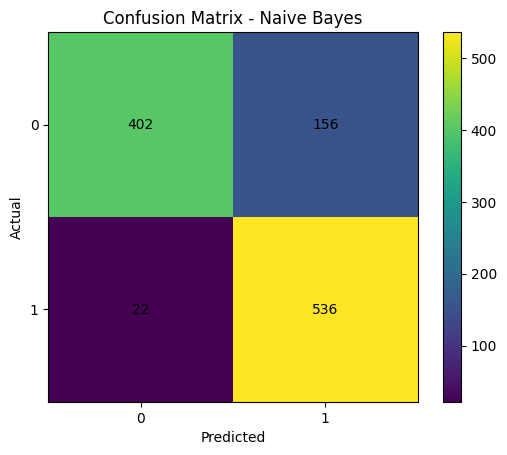

In [ ]:
plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix - Naive Bayes")
plt.colorbar()

plt.xticks([0,1])
plt.yticks([0,1])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

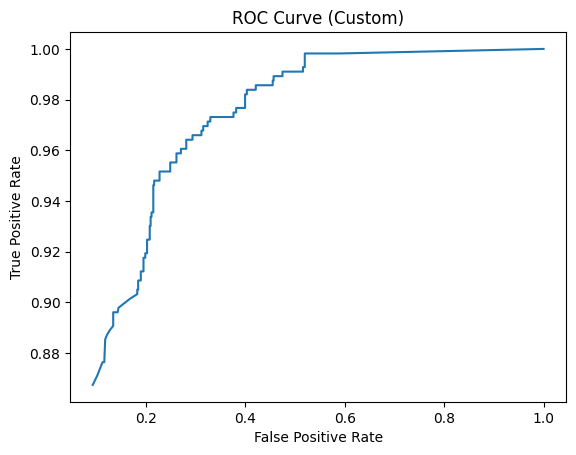

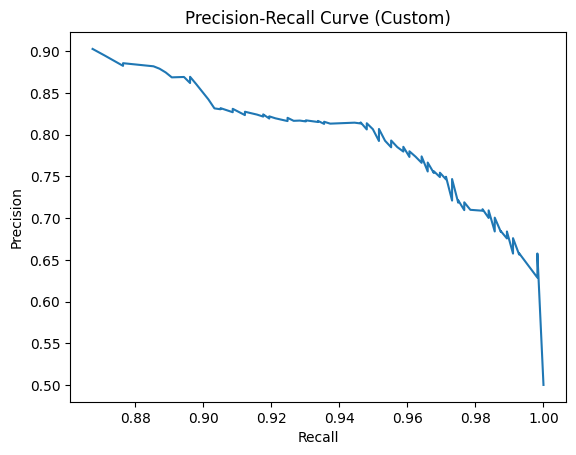

In [ ]:
# ROC Curve
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Custom)")
plt.show()

# PR Curve
plt.plot(recall_vals, precision_vals)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Custom)")
plt.show()

In [ ]:
def permutation_importance_custom(model, X, y, metric_func, n_repeats=10, random_state=42):

    np.random.seed(random_state)

    # Convert to numpy
    X = X.copy()
    X_np = X.values if hasattr(X, "values") else X
    y_np = y.values if hasattr(y, "values") else y

    n_features = X_np.shape[1]

    # Baseline score
    y_pred = model.predict(X_np)
    baseline_score = metric_func(y_np, y_pred)

    importances = np.zeros(n_features)

    for i in range(n_features):
        scores = []

        for _ in range(n_repeats):
            X_permuted = X_np.copy()

            # Shuffle one feature column
            shuffled = X_permuted[:, i].copy()
            np.random.shuffle(shuffled)
            X_permuted[:, i] = shuffled

            # Evaluate
            y_pred_perm = model.predict(X_permuted)
            score = metric_func(y_np, y_pred_perm)

            scores.append(score)

        # Importance = drop in performance
        importances[i] = baseline_score - np.mean(scores)

    return importances

In [ ]:
# FEATURE IMPORTANCE (INTERPRETABLE)

importances = permutation_importance_custom(
    nb_model,
    X_test_comb,
    y_test,
    metric_func=f1_score_custom,
    n_repeats=10
)

feature_importance_df = pd.DataFrame({
    "Feature": X_combined.columns,
    "Importance": importances
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance_df.head(10))

              Feature  Importance
26   word_freq_george    0.070863
24       word_freq_hp    0.055038
28      word_freq_lab    0.025538
25      word_freq_hpl    0.021605
41  word_freq_meeting    0.020273
45      word_freq_edu    0.014931
34       word_freq_85    0.011156
38       word_freq_pm    0.011146
40       word_freq_cs    0.011085
43  word_freq_project    0.010323


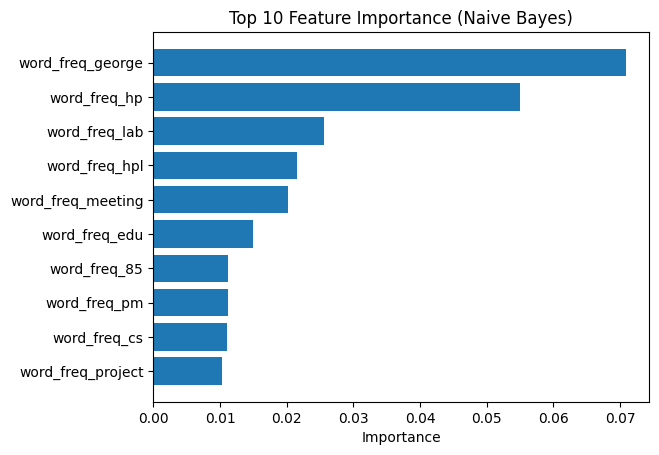

In [ ]:
top_features = feature_importance_df.head(10)

plt.figure()
plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importance (Naive Bayes)")
plt.xlabel("Importance")
plt.show()

In [ ]:
def full_evaluation_custom(model, X_train, X_test, y_train, y_test):

    # Train
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Probabilities
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)

    # CUSTOM METRICS
    acc = accuracy_score_custom(y_test, y_pred)
    prec = precision_score_custom(y_test, y_pred)
    rec = recall_score_custom(y_test, y_pred)
    f1 = f1_score_custom(y_test, y_pred)

    print("\n MODEL EVALUATION (CUSTOM)")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1:.4f}")

    # CONFUSION MATRIX (CUSTOM)
    cm = confusion_matrix_custom(y_test, y_pred)

    plt.figure()
    plt.imshow(cm)
    plt.title("Confusion Matrix (Custom)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha='center', va='center')

    plt.show()

    # ROC CURVE (CUSTOM)
    roc_auc, fpr, tpr = roc_auc_custom(y_test, y_prob)

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve (Custom)")
    plt.legend()
    plt.show()

    # PRECISION-RECALL CURVE (CUSTOM)
    pr_auc, recall_vals, precision_vals = pr_auc_custom(y_test, y_prob)

    plt.figure()
    plt.plot(recall_vals, precision_vals)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve (Custom)")
    plt.show()

    return {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc
    }


 MODEL EVALUATION (CUSTOM)
Accuracy : 0.9468
Precision: 0.9486
Recall   : 0.9146
F1 Score : 0.9313


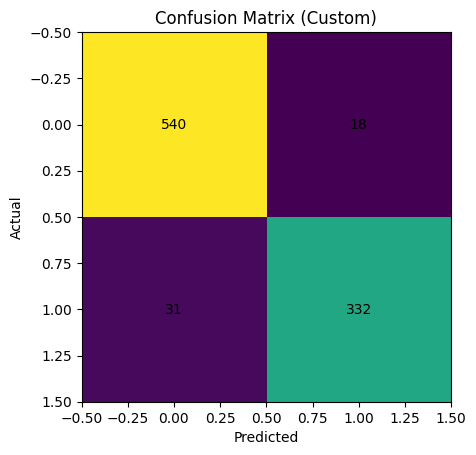

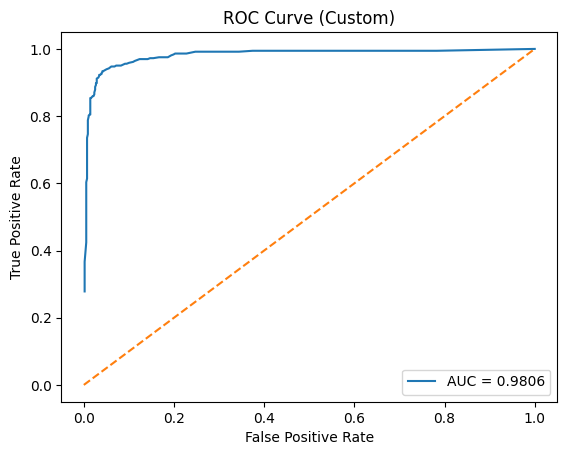

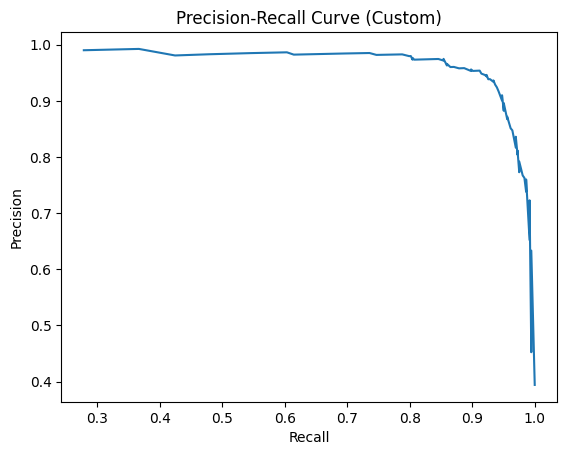

In [ ]:
from sklearn.ensemble import RandomForestClassifier

best_model = RandomForestClassifier(n_estimators=100, random_state=42)

results = full_evaluation_custom(
    best_model,
    X_train_comb,
    X_test_comb,
    y_train,
    y_test
)

In [ ]:
# UNIQUE CONTRIBUTION: ADAPTIVE THRESHOLD OPTIMIZATION (ATO)

def weighted_cost(y_true, y_pred, fp_weight=2.0, fn_weight=1.0):
    """
    Custom cost function:
    FP = ham classified as spam (high cost — user loses real email)
    FN = spam classified as ham (low cost — spam slips through)
    """
    TP, TN, FP, FN = confusion_matrix_elements(y_true, y_pred)
    return (fp_weight * FP + fn_weight * FN) / len(y_true)


def adaptive_threshold_optimizer(model, X_test, y_test,
                                  fp_weight=2.0, fn_weight=1.0,
                                  n_thresholds=200):

    y_prob = model.predict_proba(X_test)[:, 1]
    thresholds = np.linspace(0.01, 0.99, n_thresholds)

    results = []

    for thresh in thresholds:
        y_pred = (y_prob >= thresh).astype(int)

        cost  = weighted_cost(y_test, y_pred, fp_weight, fn_weight)
        acc   = accuracy_score_custom(y_test, y_pred)
        prec  = precision_score_custom(y_test, y_pred)
        rec   = recall_score_custom(y_test, y_pred)
        f1    = f1_score_custom(y_test, y_pred)

        results.append({
            "Threshold": thresh,
            "Cost":      cost,
            "Accuracy":  acc,
            "Precision": prec,
            "Recall":    rec,
            "F1 Score":  f1
        })

    results_df = pd.DataFrame(results)
    optimal_row = results_df.loc[results_df["Cost"].idxmin()]

    return optimal_row["Threshold"], results_df


print("Adaptive Threshold Optimizer defined.")

Adaptive Threshold Optimizer defined.


In [ ]:
# Apply ATO on Best Model (Random Forest, Combined Features)

from sklearn.ensemble import RandomForestClassifier

best_model = RandomForestClassifier(n_estimators=100, random_state=42)
best_model.fit(X_train_comb, y_train)

# Default threshold = 0.5
y_prob_best = best_model.predict_proba(X_test_comb)[:, 1]
y_pred_default = (y_prob_best >= 0.5).astype(int)

print("=== DEFAULT THRESHOLD (0.5) ===")
print(f"Accuracy : {accuracy_score_custom(y_test, y_pred_default):.4f}")
print(f"Precision: {precision_score_custom(y_test, y_pred_default):.4f}")
print(f"Recall   : {recall_score_custom(y_test, y_pred_default):.4f}")
print(f"F1 Score : {f1_score_custom(y_test, y_pred_default):.4f}")
print(f"Cost     : {weighted_cost(y_test, y_pred_default):.4f}")

# Run ATO
optimal_thresh, ato_results = adaptive_threshold_optimizer(
    best_model, X_test_comb, y_test,
    fp_weight=2.0, fn_weight=1.0
)

y_pred_ato = (y_prob_best >= optimal_thresh).astype(int)

print(f"\n=== ATO OPTIMAL THRESHOLD ({optimal_thresh:.4f}) ===")
print(f"Accuracy : {accuracy_score_custom(y_test, y_pred_ato):.4f}")
print(f"Precision: {precision_score_custom(y_test, y_pred_ato):.4f}")
print(f"Recall   : {recall_score_custom(y_test, y_pred_ato):.4f}")
print(f"F1 Score : {f1_score_custom(y_test, y_pred_ato):.4f}")
print(f"Cost     : {weighted_cost(y_test, y_pred_ato):.4f}")

=== DEFAULT THRESHOLD (0.5) ===
Accuracy : 0.9479
Precision: 0.9462
Recall   : 0.9201
F1 Score : 0.9330
Cost     : 0.0727

=== ATO OPTIMAL THRESHOLD (0.5123) ===
Accuracy : 0.9479
Precision: 0.9539
Recall   : 0.9118
F1 Score : 0.9324
Cost     : 0.0695


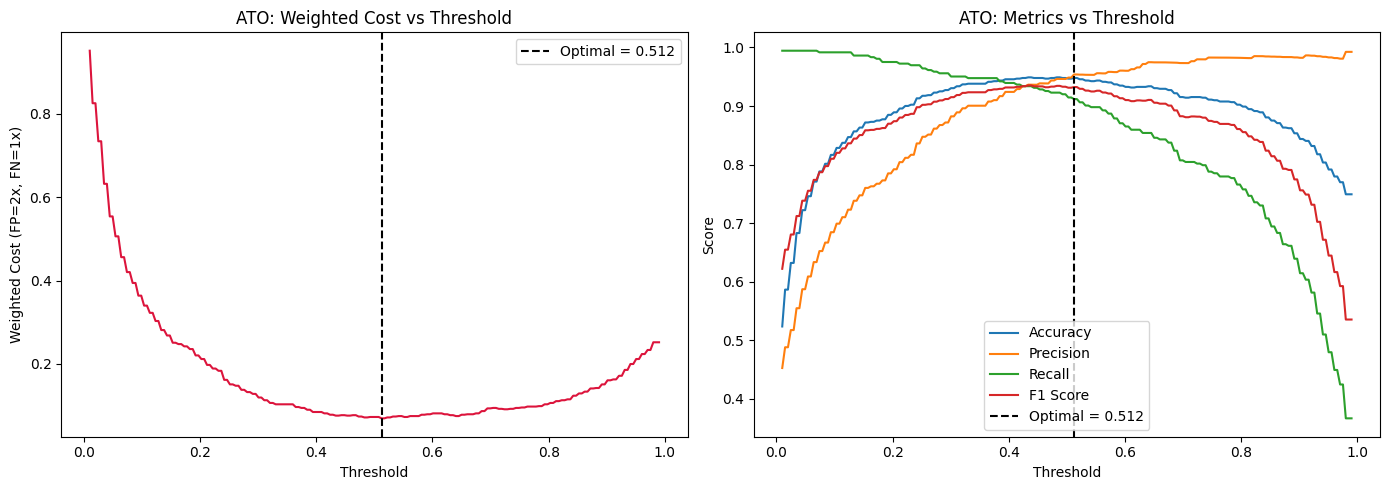

In [ ]:
# ATO Visualization

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Cost curve across thresholds
axes[0].plot(ato_results["Threshold"], ato_results["Cost"], color='crimson')
axes[0].axvline(optimal_thresh, linestyle='--', color='black',
                label=f"Optimal = {optimal_thresh:.3f}")
axes[0].set_title("ATO: Weighted Cost vs Threshold")
axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("Weighted Cost (FP=2x, FN=1x)")
axes[0].legend()

# Plot 2: Metrics across thresholds
for metric in ["Accuracy", "Precision", "Recall", "F1 Score"]:
    axes[1].plot(ato_results["Threshold"], ato_results[metric], label=metric)
axes[1].axvline(optimal_thresh, linestyle='--', color='black',
                label=f"Optimal = {optimal_thresh:.3f}")
axes[1].set_title("ATO: Metrics vs Threshold")
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("Score")
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Summary: Default vs ATO

comparison = pd.DataFrame([
    {
        "Method": "Default (threshold=0.5)",
        "Threshold": 0.5,
        "Accuracy":  accuracy_score_custom(y_test, y_pred_default),
        "Precision": precision_score_custom(y_test, y_pred_default),
        "Recall":    recall_score_custom(y_test, y_pred_default),
        "F1 Score":  f1_score_custom(y_test, y_pred_default),
        "Weighted Cost": weighted_cost(y_test, y_pred_default)
    },
    {
        "Method": f"ATO (threshold={optimal_thresh:.4f})",
        "Threshold": optimal_thresh,
        "Accuracy":  accuracy_score_custom(y_test, y_pred_ato),
        "Precision": precision_score_custom(y_test, y_pred_ato),
        "Recall":    recall_score_custom(y_test, y_pred_ato),
        "F1 Score":  f1_score_custom(y_test, y_pred_ato),
        "Weighted Cost": weighted_cost(y_test, y_pred_ato)
    }
])

print("\n=== DEFAULT vs ATO COMPARISON ===\n")
print(comparison.to_string(index=False))


=== DEFAULT vs ATO COMPARISON ===

                 Method  Threshold  Accuracy  Precision   Recall  F1 Score  Weighted Cost
Default (threshold=0.5)   0.500000  0.947883   0.946176 0.920110  0.932961       0.072747
 ATO (threshold=0.5123)   0.512312  0.947883   0.953890 0.911846  0.932394       0.069490


In [ ]:
# HYPERPARAMETER TUNING — CUSTOM GRID SEARCH

def custom_kfold_cv(X, y, k=5, random_state=42):
    np.random.seed(random_state)
    X = np.array(X)
    y = np.array(y)

    class_0 = np.where(y == 0)[0]
    class_1 = np.where(y == 1)[0]

    np.random.shuffle(class_0)
    np.random.shuffle(class_1)

    folds_0 = np.array_split(class_0, k)
    folds_1 = np.array_split(class_1, k)

    folds = []
    for i in range(k):
        val_idx = np.concatenate([folds_0[i], folds_1[i]])
        train_idx = np.concatenate(
            [np.concatenate(folds_0[:i] + folds_0[i+1:]),
             np.concatenate(folds_1[:i] + folds_1[i+1:])]
        )
        folds.append((train_idx, val_idx))

    return folds


def custom_grid_search(X_train, y_train, param_grid, k=5):
    from sklearn.ensemble import RandomForestClassifier
    from itertools import product

    # Force numpy — critical fix
    X_train = np.array(X_train)
    y_train = np.array(y_train)

    keys = list(param_grid.keys())
    values = list(param_grid.values())
    combinations = list(product(*values))

    folds = custom_kfold_cv(X_train, y_train, k=k)

    best_score = -np.inf
    best_params = None
    all_results = []

    total = len(combinations)
    print(f"Searching {total} combinations across {k} folds...\n")

    for i, combo in enumerate(combinations):
        params = dict(zip(keys, combo))

        fold_scores = []
        for train_idx, val_idx in folds:
            X_tr, X_val = X_train[train_idx], X_train[val_idx]
            y_tr, y_val = y_train[train_idx], y_train[val_idx]

            model = RandomForestClassifier(random_state=42, **params)
            model.fit(X_tr, y_tr)
            y_pred = model.predict(X_val)
            score = f1_score_custom(y_val, y_pred)
            fold_scores.append(score)

        mean_score = np.mean(fold_scores)
        std_score = np.std(fold_scores)

        all_results.append({
            **params,
            "Mean F1": mean_score,
            "Std F1": std_score
        })

        if mean_score > best_score:
            best_score = mean_score
            best_params = params

        if (i + 1) % 5 == 0 or (i + 1) == total:
            print(f"  [{i+1}/{total}] Best so far: {best_score:.4f} | Current: {mean_score:.4f} | Params: {params}")

    results_df = pd.DataFrame(all_results).sort_values("Mean F1", ascending=False)
    return best_params, best_score, results_df

print("Custom Grid Search defined.")

Custom Grid Search defined.


In [ ]:
# DEFINE PARAMETER GRID
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "max_features": ["sqrt", "log2"]
}

# Run Grid Search
best_params, best_cv_score, grid_results = custom_grid_search(
    X_train_comb, y_train,
    param_grid=param_grid,
    k=5
)

print("\n=== GRID SEARCH COMPLETE ===")
print(f"Best CV F1 Score : {best_cv_score:.4f}")
print(f"Best Parameters  : {best_params}")

Searching 36 combinations across 5 folds...

  [5/36] Best so far: 0.9751 | Current: 0.9576 | Params: {'n_estimators': 100, 'max_depth': 10, 'min_samples_split': 2, 'max_features': 'sqrt'}
  [10/36] Best so far: 0.9751 | Current: 0.9737 | Params: {'n_estimators': 100, 'max_depth': 20, 'min_samples_split': 2, 'max_features': 'log2'}
  [15/36] Best so far: 0.9760 | Current: 0.9738 | Params: {'n_estimators': 200, 'max_depth': None, 'min_samples_split': 5, 'max_features': 'sqrt'}
  [20/36] Best so far: 0.9760 | Current: 0.9537 | Params: {'n_estimators': 200, 'max_depth': 10, 'min_samples_split': 5, 'max_features': 'log2'}
  [25/36] Best so far: 0.9760 | Current: 0.9744 | Params: {'n_estimators': 300, 'max_depth': None, 'min_samples_split': 2, 'max_features': 'sqrt'}
  [30/36] Best so far: 0.9760 | Current: 0.9554 | Params: {'n_estimators': 300, 'max_depth': 10, 'min_samples_split': 2, 'max_features': 'log2'}
  [35/36] Best so far: 0.9760 | Current: 0.9721 | Params: {'n_estimators': 300, 'm

In [ ]:
# TRAIN TUNED MODEL AND COMPARE WITH DEFAULT

from sklearn.ensemble import RandomForestClassifier

# Default model
default_rf = RandomForestClassifier(n_estimators=100, random_state=42)
default_rf.fit(X_train_comb, y_train)
y_pred_default = default_rf.predict(X_test_comb)

# Tuned model
tuned_rf = RandomForestClassifier(random_state=42, **best_params)
tuned_rf.fit(X_train_comb, y_train)
y_pred_tuned = tuned_rf.predict(X_test_comb)

print("=== DEFAULT RF ===")
print(f"Accuracy : {accuracy_score_custom(y_test, y_pred_default):.4f}")
print(f"Precision: {precision_score_custom(y_test, y_pred_default):.4f}")
print(f"Recall   : {recall_score_custom(y_test, y_pred_default):.4f}")
print(f"F1 Score : {f1_score_custom(y_test, y_pred_default):.4f}")

print("\n=== TUNED RF ===")
print(f"Accuracy : {accuracy_score_custom(y_test, y_pred_tuned):.4f}")
print(f"Precision: {precision_score_custom(y_test, y_pred_tuned):.4f}")
print(f"Recall   : {recall_score_custom(y_test, y_pred_tuned):.4f}")
print(f"F1 Score : {f1_score_custom(y_test, y_pred_tuned):.4f}")

=== DEFAULT RF ===
Accuracy : 0.9468
Precision: 0.9486
Recall   : 0.9146
F1 Score : 0.9313

=== TUNED RF ===
Accuracy : 0.9511
Precision: 0.9543
Recall   : 0.9201
F1 Score : 0.9369


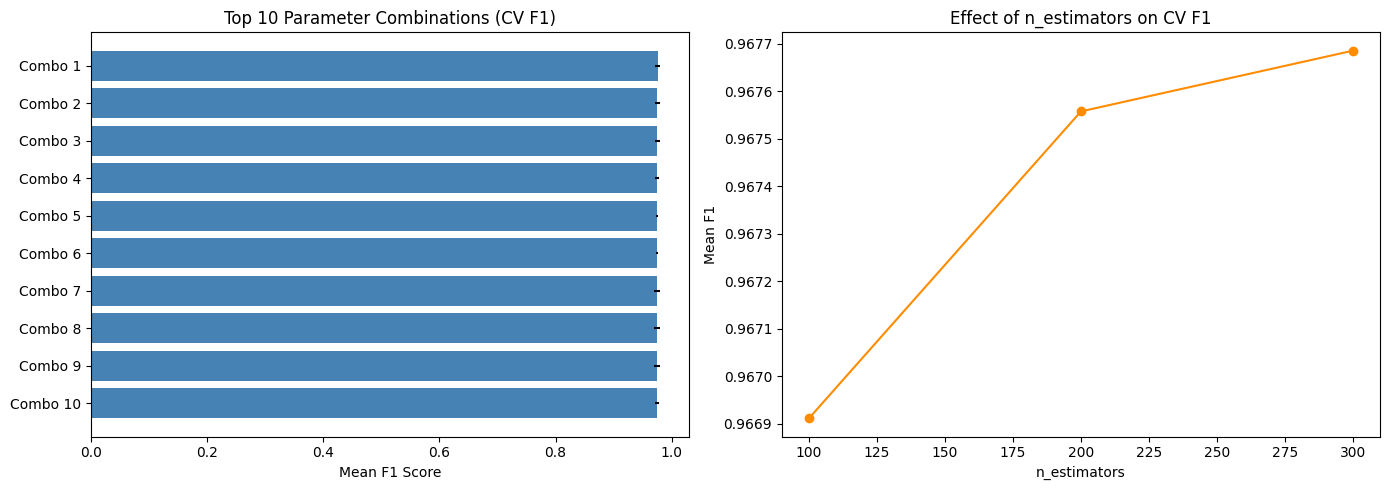


Top 5 Configurations:
 n_estimators  max_depth  min_samples_split max_features  Mean F1   Std F1
          200        NaN                  2         log2 0.975967 0.004590
          300        NaN                  2         log2 0.975305 0.004791
          200        NaN                  2         sqrt 0.975080 0.004530
          100        NaN                  2         log2 0.975065 0.003767
          200        NaN                  5         log2 0.975006 0.001743


In [ ]:
# VISUALIZE TUNING RESULTS

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Top 10 parameter combinations by Mean F1
top10 = grid_results.head(10).reset_index(drop=True)
axes[0].barh(
    [f"Combo {i+1}" for i in range(len(top10))],
    top10["Mean F1"],
    xerr=top10["Std F1"],
    color="steelblue"
)
axes[0].invert_yaxis()
axes[0].set_title("Top 10 Parameter Combinations (CV F1)")
axes[0].set_xlabel("Mean F1 Score")

# Plot 2: Effect of n_estimators on F1
n_est_results = grid_results.groupby("n_estimators")["Mean F1"].mean()
axes[1].plot(n_est_results.index, n_est_results.values, marker='o', color='darkorange')
axes[1].set_title("Effect of n_estimators on CV F1")
axes[1].set_xlabel("n_estimators")
axes[1].set_ylabel("Mean F1")

plt.tight_layout()
plt.show()

print("\nTop 5 Configurations:")
print(grid_results.head(5).to_string(index=False))

In [ ]:
# TRAIN TUNED MODEL AND COMPARE WITH DEFAULT

from sklearn.ensemble import RandomForestClassifier

# Default model
default_rf = RandomForestClassifier(n_estimators=100, random_state=42)
default_rf.fit(X_train_comb, y_train)
y_pred_default_rf = default_rf.predict(X_test_comb)

# Tuned model
tuned_rf = RandomForestClassifier(random_state=42, **best_params)
tuned_rf.fit(X_train_comb, y_train)
y_pred_tuned_rf = tuned_rf.predict(X_test_comb)

# Comparison table
tuning_comparison = pd.DataFrame([
    {
        "Model": "Default RF (n=100)",
        "Accuracy":  accuracy_score_custom(y_test, y_pred_default_rf),
        "Precision": precision_score_custom(y_test, y_pred_default_rf),
        "Recall":    recall_score_custom(y_test, y_pred_default_rf),
        "F1 Score":  f1_score_custom(y_test, y_pred_default_rf),
    },
    {
        "Model": f"Tuned RF {best_params}",
        "Accuracy":  accuracy_score_custom(y_test, y_pred_tuned_rf),
        "Precision": precision_score_custom(y_test, y_pred_tuned_rf),
        "Recall":    recall_score_custom(y_test, y_pred_tuned_rf),
        "F1 Score":  f1_score_custom(y_test, y_pred_tuned_rf),
    }
])

print("\n=== DEFAULT vs TUNED RF ===\n")
print(tuning_comparison.to_string(index=False))


=== DEFAULT vs TUNED RF ===

                                                                                            Model  Accuracy  Precision   Recall  F1 Score
                                                                               Default RF (n=100)  0.946797   0.948571 0.914601  0.931276
Tuned RF {'n_estimators': 200, 'max_depth': None, 'min_samples_split': 2, 'max_features': 'log2'}  0.951140   0.954286 0.920110  0.936886


In [ ]:
# SHAP INTERPRETABILITY ON TUNED RANDOM FOREST

import shap

# TreeExplainer without background data for RF (more stable)
explainer = shap.TreeExplainer(tuned_rf)

# Compute SHAP values
shap_values = explainer.shap_values(X_test_comb, check_additivity=False)

# For binary classification RF, shap_values is [class_0_array, class_1_array]
# Use class 1 (spam)
if isinstance(shap_values, list):
    shap_vals_spam = shap_values[1]
else:
    shap_vals_spam = shap_values[..., 1]

# Feature names
feature_names = list(X_combined.columns)

print("SHAP values computed successfully.")
print(f"SHAP values shape: {shap_vals_spam.shape}")
print(f"Expected value (base rate): {explainer.expected_value[1]:.4f}")

SHAP values computed successfully.
SHAP values shape: (921, 61)
Expected value (base rate): 0.5005


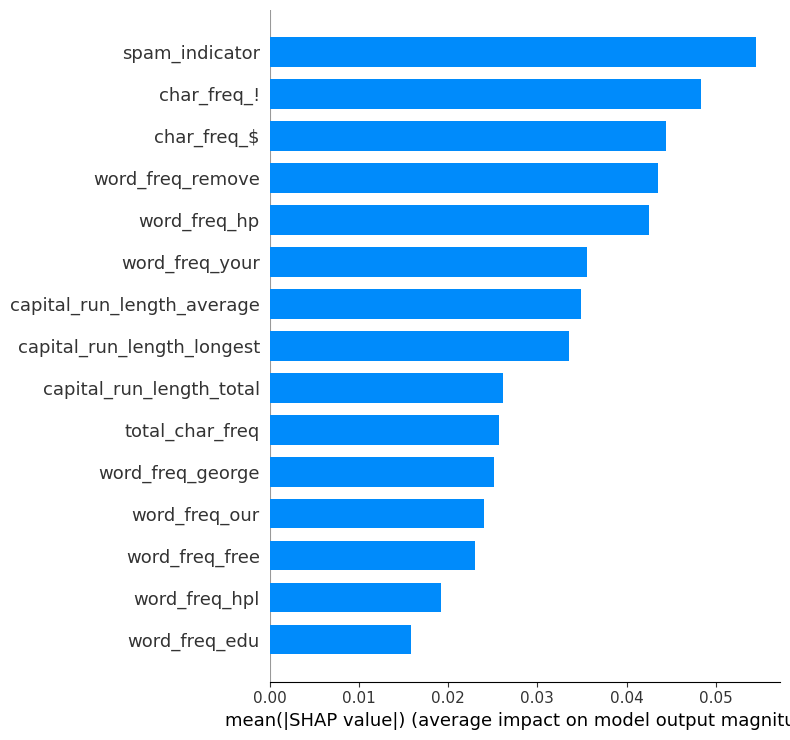

In [ ]:
# SHAP PLOT 1: Global Feature Importance (Bar)

shap.summary_plot(
    shap_vals_spam,
    X_test_comb,
    feature_names=feature_names,
    plot_type="bar",
    max_display=15,
    show=True
)

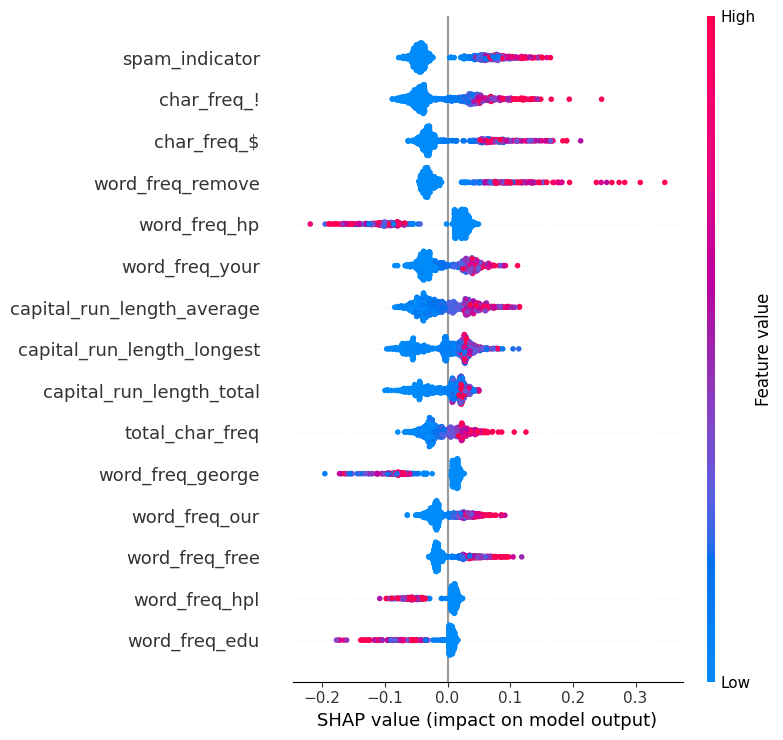

In [ ]:
# SHAP PLOT 2: Beeswarm Plot

shap.summary_plot(
    shap_vals_spam,
    X_test_comb,
    feature_names=feature_names,
    max_display=15,
    show=True
)

Using 50 samples closest to ATO threshold (0.5123)
Their probabilities range: 0.4100 - 0.6150
shap_boundary shape: (50, 61)
X_boundary shape: (50, 61)


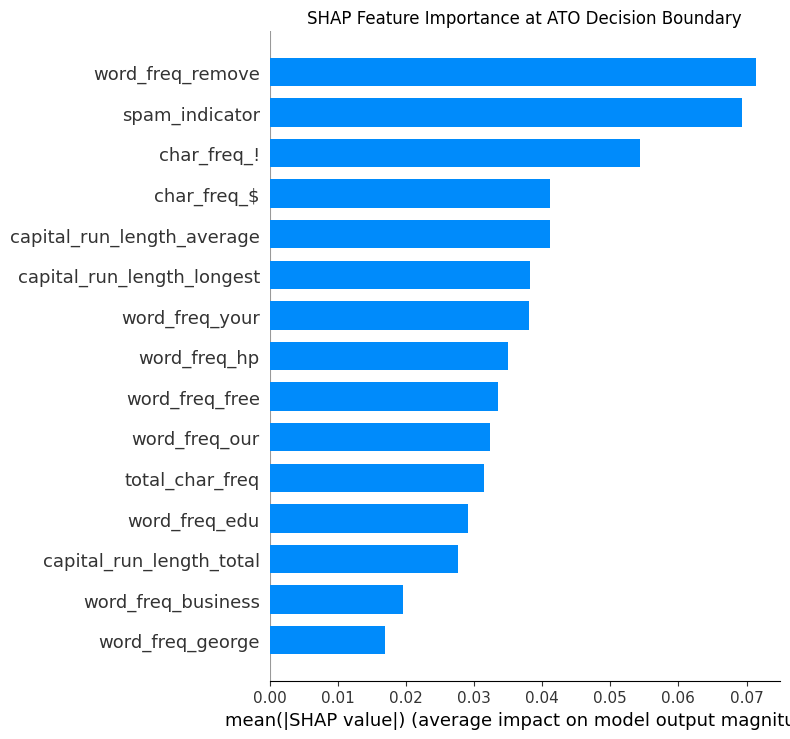

In [ ]:
# SHAP AT ATO BOUNDARY

y_prob_tuned = tuned_rf.predict_proba(X_test_comb)[:, 1]

# 50 closest samples to threshold
distances = np.abs(y_prob_tuned - optimal_thresh)
boundary_indices = np.argsort(distances)[:50]

print(f"Using 50 samples closest to ATO threshold ({optimal_thresh:.4f})")
print(f"Their probabilities range: {y_prob_tuned[boundary_indices].min():.4f} - {y_prob_tuned[boundary_indices].max():.4f}")

shap_boundary = shap_vals_spam[boundary_indices]
X_boundary = X_test_comb[boundary_indices]

# Verify non-empty
print(f"shap_boundary shape: {shap_boundary.shape}")
print(f"X_boundary shape: {X_boundary.shape}")

# Plot with show=False so matplotlib retains control
shap.summary_plot(
    shap_boundary,
    X_boundary,
    feature_names=feature_names,
    max_display=15,
    plot_type="bar",
    show=False
)

plt.title("SHAP Feature Importance at ATO Decision Boundary")
plt.tight_layout()
plt.show()

Base value (expected): 0.5005
Sample probability   : 0.5100


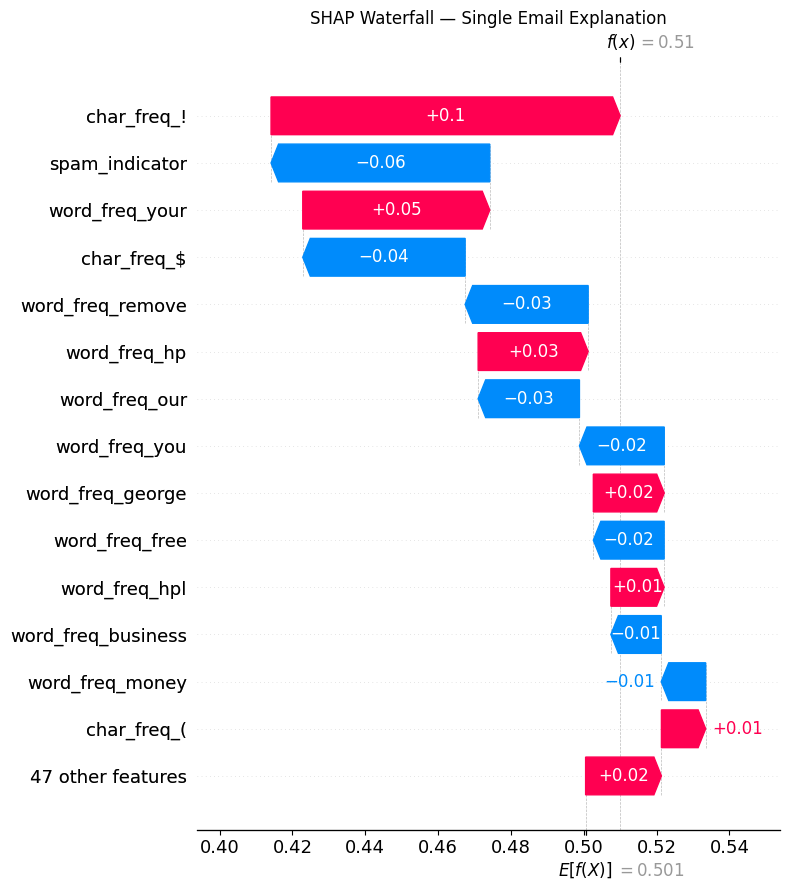

In [ ]:
# SHAP PLOT 3: Waterfall — Single Email Explanation

sample_idx = boundary_indices[0]

# Get scalar expected value for class 1 (spam)
if isinstance(explainer.expected_value, (list, np.ndarray)):
    base_value = float(explainer.expected_value[1])
else:
    base_value = float(explainer.expected_value)

print(f"Base value (expected): {base_value:.4f}")
print(f"Sample probability   : {y_prob_tuned[sample_idx]:.4f}")

shap.plots._waterfall.waterfall_legacy(
    base_value,
    shap_vals_spam[sample_idx],
    feature_names=feature_names,
    max_display=15,
    show=False
)

plt.title("SHAP Waterfall — Single Email Explanation")
plt.tight_layout()
plt.show()